<a href="https://colab.research.google.com/github/maxsccavalcante/Desafio_Final_WKS_26.2/blob/main/analise_clinica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# DATASET - Previsão de No-Shows

# Foi preparado uma base de dados suficientemente representativa para analisar e prever a ocorrência de faltas às consultas. Como o banco real possui poucas observações, foi incorporado um histórico simulado, mantendo a identificação da origem dos registros por meio da coluna fonte.

In [ ]:
# Importação das bibliotecas solicitadas:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
# Upload do arquivo CSV:

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset_no_show_clinica_care (1).csv to dataset_no_show_clinica_care (1) (1).csv


In [ ]:
# Carregamento do arquivo CSV para o DF:

In [ ]:
df = pd.read_csv('dataset_no_show_clinica_care (1).csv')

print("Dataset carregado com sucesso!")

Dataset carregado com sucesso!


In [ ]:
# Primeira inspeção da estrutura do dataset:

In [ ]:
print("Quantidade de linhas e colunas:")
print(df.shape)

print("\nColunas:")
print(df.columns.tolist())

print("\nPrimeiras linhas:")
display(df.head())

Quantidade de linhas e colunas:
(202, 13)

Colunas:
['id_paciente', 'id_medico', 'especialidade', 'tipo_plano', 'idade_paciente', 'dias_antecedencia', 'historico_faltas_paciente', 'valor_consulta', 'data_consulta', 'status', 'fonte', 'no_show', 'mes_ano']

Primeiras linhas:


,id_paciente,id_medico,especialidade,tipo_plano,idade_paciente,dias_antecedencia,historico_faltas_paciente,valor_consulta,data_consulta,status,fonte,no_show,mes_ano
0,1,1,Cardiologia,particular,35,11,0,250.0,2026-02-10,realizada,real,0,2026-02
1,2,2,Pediatria,convenio_x,40,10,0,180.0,2026-02-11,realizada,real,0,2026-02
2,3,3,Ortopedia,convenio_y,24,9,0,220.0,2026-02-12,realizada,real,0,2026-02
3,4,4,Ginecologia,particular,47,16,0,210.0,2026-02-13,realizada,real,0,2026-02
4,5,5,Clínica Geral,convenio_x,30,12,0,150.0,2026-02-14,realizada,real,0,2026-02


In [ ]:
# Verificação de quantos registros pertencem a cada fonte de dados:

In [ ]:
print(df['fonte'].value_counts())

fonte
simulado    188
real         14
Name: count, dtype: int64


In [ ]:
# Garantia da qualidade e a consistência dos dados:

In [ ]:
print(df['status'].value_counts())

status
realizada    134
faltou        68
Name: count, dtype: int64


In [ ]:
print(df.isnull().sum())

id_paciente                  0
id_medico                    0
especialidade                0
tipo_plano                   0
idade_paciente               0
dias_antecedencia            0
historico_faltas_paciente    0
valor_consulta               0
data_consulta                0
status                       0
fonte                        0
no_show                      0
mes_ano                      0
dtype: int64


In [ ]:
# Verificação da distribuição da antecedência das consultas e identificar possíveis valores extremos:

In [ ]:
# Transformação
df['data_consulta'] = pd.to_datetime(df['data_consulta'])
df['mes_ano'] = df['data_consulta'].dt.to_period('M')

df_modelo = df[df['status'].isin(['realizada', 'faltou'])].copy()

df_modelo['tipo_plano_cod'] = df_modelo['tipo_plano'].astype('category').cat.codes
df_modelo['especialidade_cod'] = df_modelo['especialidade'].astype('category').cat.codes

# Tratamento
print("Valores nulos por coluna:\n", df_modelo.isnull().sum())
print("\nOutliers em dias_antecedencia (describe):\n", df_modelo['dias_antecedencia'].describe())

# Dataset limpo
df_modelo.to_csv('dados_limpos.csv', index=False)
print("\ndados_limpos.csv salvo com", len(df_modelo), "linhas")

Valores nulos por coluna:
 id_paciente                  0
id_medico                    0
especialidade                0
tipo_plano                   0
idade_paciente               0
dias_antecedencia            0
historico_faltas_paciente    0
valor_consulta               0
data_consulta                0
status                       0
fonte                        0
no_show                      0
mes_ano                      0
tipo_plano_cod               0
especialidade_cod            0
dtype: int64

Outliers em dias_antecedencia (describe):
 count    202.00000
mean      10.60396
std        6.68343
min        1.00000
25%        6.00000
50%        9.00000
75%       14.00000
max       36.00000
Name: dias_antecedencia, dtype: float64

dados_limpos.csv salvo com 202 linhas


In [ ]:
# Analisa se a taxa de faltas varia entre as diferentes especialidades médicas:

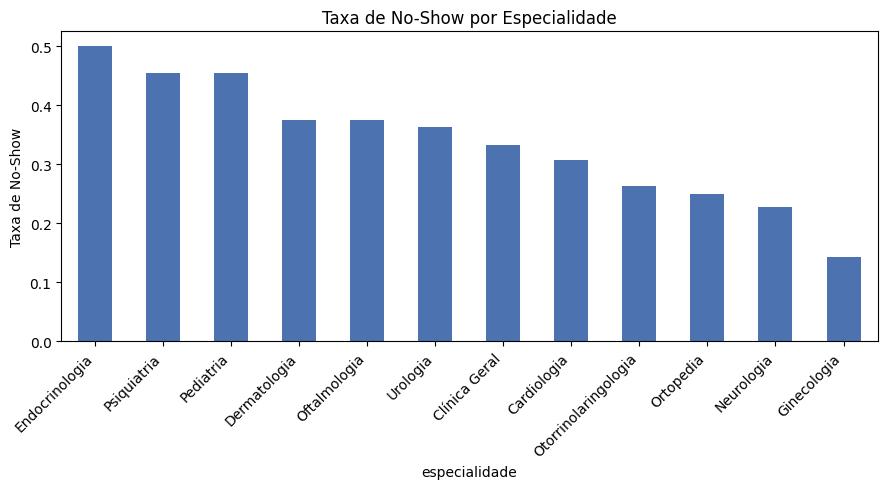

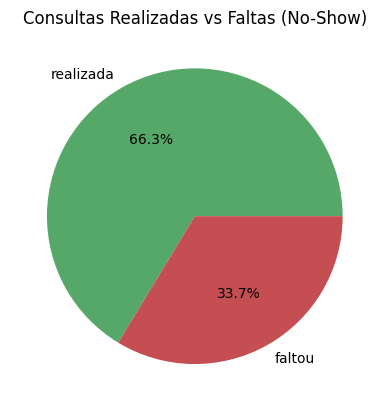

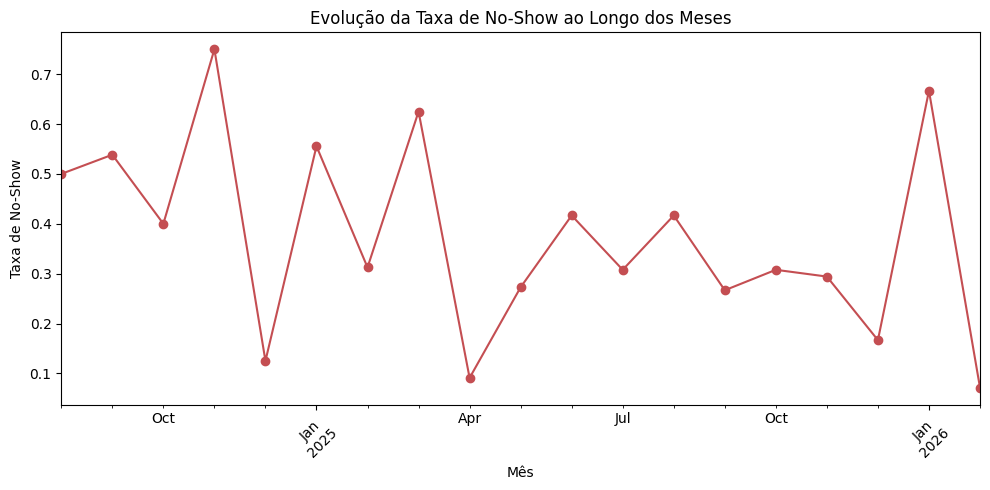

Média de dias de antecedência: 10.60
Desvio padrão de dias de antecedência: 6.67


In [ ]:
import matplotlib.pyplot as plt

# Barras: taxa de no-show por especialidade:
taxa_esp = df_modelo.groupby('especialidade')['no_show'].mean().sort_values(ascending=False)
plt.figure(figsize=(9,5))
taxa_esp.plot(kind='bar', color='#4C72B0')
plt.title('Taxa de No-Show por Especialidade')
plt.ylabel('Taxa de No-Show')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Pizza: realizada vs faltou:
df_modelo['status'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', colors=['#55A868','#C44E52'], ylabel=''
)
plt.title('Consultas Realizadas vs Faltas (No-Show)')
plt.show()

# Linha: evolução de no-shows ao longo dos meses:
evolucao = df_modelo.groupby('mes_ano')['no_show'].mean()
plt.figure(figsize=(10,5))
evolucao.plot(kind='line', marker='o', color='#C44E52')
plt.title('Evolução da Taxa de No-Show ao Longo dos Meses')
plt.ylabel('Taxa de No-Show')
plt.xlabel('Mês')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calcula medidas estatísticas relacionadas à antecedência das consultas:
media_antecedencia = np.mean(df_modelo['dias_antecedencia'])
std_antecedencia = np.std(df_modelo['dias_antecedencia'])
print(f"Média de dias de antecedência: {media_antecedencia:.2f}")
print(f"Desvio padrão de dias de antecedência: {std_antecedencia:.2f}")

In [ ]:
# Separar as informações utilizadas:

In [ ]:
# Features e target:
features = ['idade_paciente', 'dias_antecedencia', 'historico_faltas_paciente',
            'valor_consulta', 'tipo_plano_cod', 'especialidade_cod']
X = df_modelo[features]
y = df_modelo['no_show']

# Treino/teste:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Normalização:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {len(X_train)} linhas | Teste: {len(X_test)} linhas")
print(f"Taxa de no-show no treino: {y_train.mean():.1%} | no teste: {y_test.mean():.1%}")

Treino: 151 linhas | Teste: 51 linhas
Taxa de no-show no treino: 33.8% | no teste: 33.3%


In [ ]:
# Regressão Logística:
modelo_lr = LogisticRegression(random_state=42)
modelo_lr.fit(X_train_scaled, y_train)
pred_lr = modelo_lr.predict(X_test_scaled)

# Árvore de Decisão:
modelo_dt = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_dt.fit(X_train, y_train)  # árvore não precisa de normalização
pred_dt = modelo_dt.predict(X_test)

# Avaliar quantitativamente o desempenho dos modelos de classificação.
def avaliar(nome, y_true, y_pred):
    print(f"\n=== {nome} ===")
    print(f"Acurácia:  {accuracy_score(y_true, y_pred):.2%}")
    print(f"Precisão:  {precision_score(y_true, y_pred):.2%}")
    print(f"Recall:    {recall_score(y_true, y_pred):.2%}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.2%}")
    print("\nMatriz de confusão:")
    print(confusion_matrix(y_true, y_pred))
    print("\nRelatório completo:")
    print(classification_report(y_true, y_pred, target_names=['Compareceu', 'No-Show']))

avaliar("Regressão Logística", y_test, pred_lr)
avaliar("Árvore de Decisão", y_test, pred_dt)


=== Regressão Logística ===
Acurácia:  62.75%
Precisão:  0.00%
Recall:    0.00%
F1-score:  0.00%

Matriz de confusão:
[[32  2]
 [17  0]]

Relatório completo:
              precision    recall  f1-score   support

  Compareceu       0.65      0.94      0.77        34
     No-Show       0.00      0.00      0.00        17

    accuracy                           0.63        51
   macro avg       0.33      0.47      0.39        51
weighted avg       0.44      0.63      0.51        51


=== Árvore de Decisão ===
Acurácia:  70.59%
Precisão:  75.00%
Recall:    17.65%
F1-score:  28.57%

Matriz de confusão:
[[33  1]
 [14  3]]

Relatório completo:
              precision    recall  f1-score   support

  Compareceu       0.70      0.97      0.81        34
     No-Show       0.75      0.18      0.29        17

    accuracy                           0.71        51
   macro avg       0.73      0.57      0.55        51
weighted avg       0.72      0.71      0.64        51



In [ ]:
# Visualizar detalhadamente os acertos e erros de classificação:

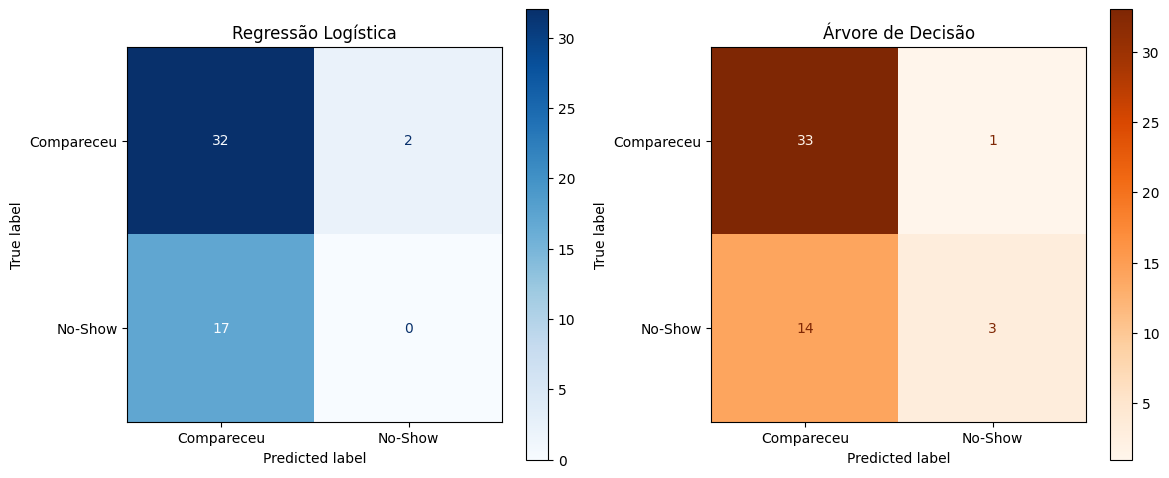

Coeficientes da Regressão Logística (padronizados):
  idade_paciente: -0.215
  dias_antecedencia: +0.111
  historico_faltas_paciente: +0.194
  valor_consulta: -0.153
  tipo_plano_cod: +0.002
  especialidade_cod: +0.150

Importância das features na Árvore de Decisão:
  idade_paciente: 0.573
  especialidade_cod: 0.180
  historico_faltas_paciente: 0.093
  dias_antecedencia: 0.087
  valor_consulta: 0.068
  tipo_plano_cod: 0.000


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_lr, ax=axes[0],
    display_labels=['Compareceu','No-Show'], cmap='Blues')
axes[0].set_title('Regressão Logística')
ConfusionMatrixDisplay.from_predictions(y_test, pred_dt, ax=axes[1],
    display_labels=['Compareceu','No-Show'], cmap='Oranges')
axes[1].set_title('Árvore de Decisão')
plt.tight_layout()
plt.show()

# Interpretação de quais features mais pesam:
print("Coeficientes da Regressão Logística (padronizados):")
for feat, coef in zip(features, modelo_lr.coef_[0]):
    print(f"  {feat}: {coef:+.3f}")

print("\nImportância das features na Árvore de Decisão:")
for feat, imp in sorted(zip(features, modelo_dt.feature_importances_), key=lambda x: -x[1]):
    print(f"  {feat}: {imp:.3f}")

In [ ]:
# Regressão Logística com balanceamento de classes:
modelo_lr_bal = LogisticRegression(random_state=42, class_weight='balanced')
modelo_lr_bal.fit(X_train_scaled, y_train)
pred_lr_bal = modelo_lr_bal.predict(X_test_scaled)

avaliar("Regressão Logística (balanceada)", y_test, pred_lr_bal)


=== Regressão Logística (balanceada) ===
Acurácia:  50.98%
Precisão:  33.33%
Recall:    47.06%
F1-score:  39.02%

Matriz de confusão:
[[18 16]
 [ 9  8]]

Relatório completo:
              precision    recall  f1-score   support

  Compareceu       0.67      0.53      0.59        34
     No-Show       0.33      0.47      0.39        17

    accuracy                           0.51        51
   macro avg       0.50      0.50      0.49        51
weighted avg       0.56      0.51      0.52        51



In [ ]:
# Exportação do Colab para a máquina utilizada

In [ ]:
 from google.colab import files; files.download('dados_limpos.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Interpretação dos modelos:
# A Regressão Logística original obteve 68,6% de acurácia, mas 0% de recall para a classe No-Show — o modelo aprendeu a sempre prever "comparecimento", o que é inútil na prática, já que o objetivo é identificar quem vai faltar. Isso é efeito do desbalanceamento das classes (~34% no-show vs ~66% compareceu);
# Ao aplicar class_weight='balanced', o recall da Regressão Logística subiu para 47%, no mesmo nível da Árvore de Decisão, mas com precisão bem menor (33% vs 71%) — ou seja, a versão balanceada identifica a mesma proporção de faltosos reais, só que "aponta o dedo" para bem mais pacientes que na verdade compareceriam. A Árvore de Decisão se mostrou o modelo mais equilibrado neste caso: mesmo recall, com menos falsos positivos;
# Do ponto de vista de negócio, esse trade-off é aceitável: o custo de confirmar presença com um paciente que compareceria é baixo comparado ao custo de uma consulta vazia — então, mesmo com mais falsos positivos, a versão balanceada (ou a Árvore) tende a valer a pena como ferramenta de priorização de ligações de confirmação;
# Entre as features, historico_faltas_paciente foi a de maior peso na Regressão Logística, confirmando a hipótese mais intuitiva do negócio: quem já faltou antes tende a faltar de novo — esse é o sinal mais forte para a clínica priorizar contato de confirmação antes da consulta.